# **Customer Churn Prediction με Logistic Regression σε Python**

Αυτό το notebook αναπαράγει το Azure Machine Learning pipeline που φτιάξαμε για πρόβλεψη Customer Churn.

## **Το Pipeline στο Azure περιείχε τα εξής βήματα:**
1. **CustomerChurnClean** — Φόρτωση του dataset
2. **Clean Missing Data** — Καθαρισμός ελλιπών τιμών
3. **Split Data** — Χωρισμός σε train/test set
4. **Two-Class Logistic Regression** — Ορισμός του μοντέλου
5. **Train Model** — Εκπαίδευση του μοντέλου
6. **Score Model** — Πρόβλεψη στο test set
7. **Evaluate Model** — Αξιολόγηση αποτελεσμάτων

---

## **Βήμα 1 - Φόρτωση του Dataset (CustomerChurnClean)**

Κάνουμε upload το αρχείο `CustomerChurnClean.csv` και το φορτώνουμε στο pandas.

> 📁 **Σημείωση:** Βεβαιωθείτε ότι το αρχείο CustomerChurnClean.csv είναι διαθέσιμο στο περιβάλλον εργασίας σας (στον ίδιο φάκελο ή ανεβασμένο στο session storage).

In [63]:
# Import βιβλιοθηκών
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)

print("✅ Βιβλιοθήκες φορτώθηκαν επιτυχώς!")

✅ Βιβλιοθήκες φορτώθηκαν επιτυχώς!


In [64]:
# Φόρτωση του dataset (το αρχείο χρησιμοποιεί ; ως διαχωριστικό)
df = pd.read_csv('CustomerChurnClean.csv', sep=';')

print(f"📊 Σχήμα dataset: {df.shape[0]} γραμμές x {df.shape[1]} στήλες")
print(f"\n📋 Στήλες:")
print(df.columns.tolist())
df.head()

📊 Σχήμα dataset: 7043 γραμμές x 23 στήλες

📋 Στήλες:
['Churn', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'InternetService', 'ContractMonthToMonth', 'Contract1Year', 'Contract2Year', 'PaymentMethodECheck', 'PaymentMethodCC', 'PaymentMethodACH', 'PaymentMethodMail']


,Churn,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,PhoneService,OnlineSecurity,OnlineBackup,...,StreamingMovies,PaperlessBilling,InternetService,ContractMonthToMonth,Contract1Year,Contract2Year,PaymentMethodECheck,PaymentMethodCC,PaymentMethodACH,PaymentMethodMail
0,No,1,29.85,29.85,0,1,0,0,0,1,...,0,1,1,1,0,0,1,0,0,0
1,No,34,56.95,1889.50,0,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,1
2,Yes,2,53.85,108.15,0,0,0,1,1,1,...,0,1,1,1,0,0,0,0,0,1
3,No,45,42.30,1840.75,0,0,0,0,1,0,...,0,0,1,0,1,0,0,0,1,0
4,Yes,2,70.70,151.65,0,0,0,1,0,0,...,0,1,1,1,0,0,1,0,0,0


---
## **Βήμα 2 - Clean Missing Data**

Αντιστοιχεί στο module `clean_missing_data` του Azure.
Ελέγχουμε για ελλιπείς τιμές και τις διαχειριζόμαστε.

In [65]:
# Έλεγχος ελλιπών τιμών
missing = df.isnull().sum()
print("🔍 Ελλιπείς τιμές ανά στήλη:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ Δεν υπάρχουν ελλιπείς τιμές!")
print(f"\nΣύνολο ελλιπών τιμών: {df.isnull().sum().sum()}")

🔍 Ελλιπείς τιμές ανά στήλη:
TotalCharges    11
dtype: int64

Σύνολο ελλιπών τιμών: 11


In [66]:
# Αφαίρεση γραμμών με ελλιπείς τιμές (αντίστοιχο του Azure Clean Missing Data)
df_clean = df.dropna()

# Μετατροπή της στήλης Churn (target) σε αριθμητική (0/1)
df_clean = df_clean.copy()
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print(f"📊 Dataset μετά τον καθαρισμό: {df_clean.shape[0]} γραμμές x {df_clean.shape[1]} στήλες")
print(f"\n🎯 Κατανομή target (Churn):")
print(df_clean['Churn'].value_counts())
print(f"\nΠοσοστό Churn: {df_clean['Churn'].mean()*100:.2f}%")

📊 Dataset μετά τον καθαρισμό: 7032 γραμμές x 23 στήλες

🎯 Κατανομή target (Churn):
Churn
0    5163
1    1869
Name: count, dtype: int64

Ποσοστό Churn: 26.58%


---
## **Βήμα 3 - Split Data**

Αντιστοιχεί στο module `split_data` του Azure.
Χωρίζουμε σε features (X) και target (y), και μετά σε train/test set.

In [67]:
# Ορισμός features (X) και target (y)
target_col = 'Churn'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"Features (X): {X.shape[1]} στήλες")
print(f"Target (y): '{target_col}'")

# Train/Test split — 70% train, 30% test (αντίστοιχο του Azure Split Data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
# Το random_state=42 διασφαλίζει την αναπαραγωγιμότητα των αποτελεσμάτων
# (ώστε να παίρνουμε τα ίδια δείγματα κάθε φορά που τρέχει ο κώδικας)
print(f"\n📂 Train set: {X_train.shape[0]} δείγματα")
print(f"📂 Test set:  {X_test.shape[0]} δείγματα")

Features (X): 22 στήλες
Target (y): 'Churn'

📂 Train set: 4922 δείγματα
📂 Test set:  2110 δείγματα


---
## **Βήμα 4 - Two-Class Logistic Regression**

Αντιστοιχεί στο module `two_class_logistic_regression` του Azure.
Ορίζουμε το μοντέλο Logistic Regression.

In [68]:
# Ορισμός του μοντέλου Two-Class Logistic Regression
# (αντίστοιχο του Azure Two-Class Logistic Regression module)
logistic_model = LogisticRegression(
    max_iter=1000,        # Μέγιστος αριθμός επαναλήψεων
    random_state=42,      # Αναπαραγωγιμότητα
    solver='lbfgs'        # Solver κατάλληλος για binary classification
)

print("✅ Μοντέλο Logistic Regression ορίστηκε:")
print(logistic_model)

✅ Μοντέλο Logistic Regression ορίστηκε:
LogisticRegression(max_iter=1000, random_state=42)


---
## **Βήμα 5 - Train Model**

Αντιστοιχεί στο module `train_model` του Azure.
Εκπαιδεύουμε το μοντέλο στο training set.

In [69]:
# Εκπαίδευση του μοντέλου (Train Model)
logistic_model.fit(X_train, y_train)

print("✅ Το μοντέλο εκπαιδεύτηκε επιτυχώς!")
print(f"\nΑριθμός features: {logistic_model.n_features_in_}")
print(f"Classes: {logistic_model.classes_} (0=No Churn, 1=Churn)")

✅ Το μοντέλο εκπαιδεύτηκε επιτυχώς!

Αριθμός features: 22
Classes: [0 1] (0=No Churn, 1=Churn)


---
## **Βήμα 6 - Score Model**

Αντιστοιχεί στο module `score_model` του Azure.
Εφαρμόζουμε το εκπαιδευμένο μοντέλο στο test set για πρόβλεψη.

In [70]:
# Score Model — Πρόβλεψη στο test set
y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]  # Πιθανότητα Churn=1

# Προβολή scored dataset (πρώτες 10 γραμμές)
scored_df = X_test.copy()
scored_df['Scored Labels'] = y_pred
scored_df['Scored Probabilities'] = y_pred_proba
scored_df['Actual Churn'] = y_test.values

print("📋 Scored Dataset (πρώτες 10 γραμμές):")
scored_df[['Scored Labels', 'Scored Probabilities', 'Actual Churn']].head(10)

📋 Scored Dataset (πρώτες 10 γραμμές):


,Scored Labels,Scored Probabilities,Actual Churn
2481,0,0.005897,0
6784,0,0.128981,0
6125,1,0.712187,1
3052,0,0.129123,0
4099,0,0.364304,0
3223,0,0.458724,0
3774,0,0.122408,0
3469,1,0.753528,0
3420,0,0.226893,0
1196,0,0.021508,0


---
## **Βήμα 7 - Evaluate Model**

Αντιστοιχεί στο module `evaluate_model` του Azure.
Αξιολογούμε την απόδοση του μοντέλου με όλες τις βασικές μετρικές.

In [71]:
# Evaluate Model — Βασικές μετρικές
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("📊 Evaluation Results (Test Set)")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 40)

# Train metrics για σύγκριση
y_train_pred = logistic_model.predict(X_train)
print(f"\n📊 Train Set Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")

📊 Evaluation Results (Test Set)
  Accuracy  : 0.7991
  Precision : 0.6389
  Recall    : 0.5397
  F1-Score  : 0.5851
  ROC-AUC   : 0.8426

📊 Train Set Accuracy: 0.8056


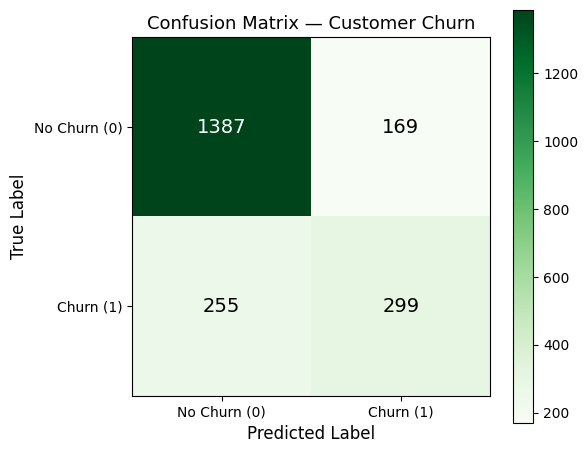


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1556
       Churn       0.64      0.54      0.59       554

    accuracy                           0.80      2110
   macro avg       0.74      0.72      0.73      2110
weighted avg       0.79      0.80      0.79      2110



In [72]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
plt.colorbar(im, ax=ax)

classes = ['No Churn (0)', 'Churn (1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Customer Churn', fontsize=13)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

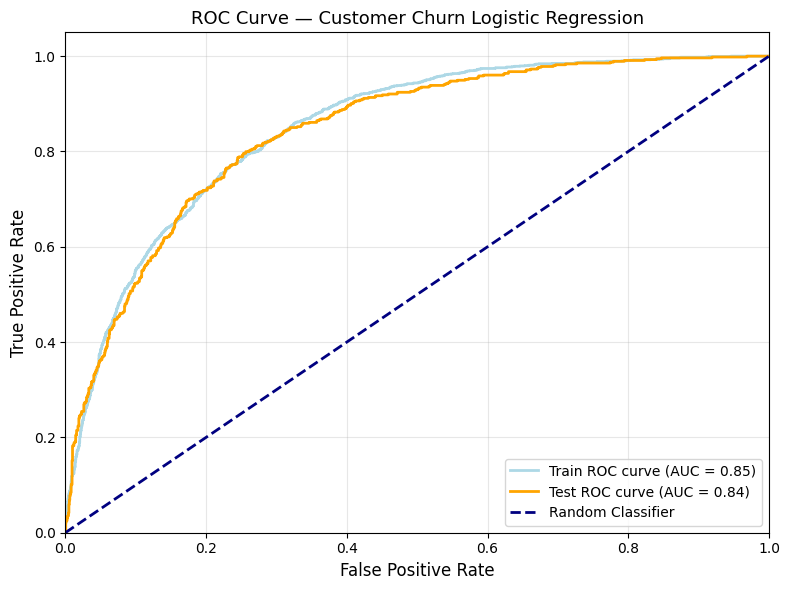

In [73]:
# ROC Curve — Train vs Test
y_train_proba = logistic_model.predict_proba(X_train)[:, 1]

fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)

roc_auc_test  = auc(fpr_test, tpr_test)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='lightblue', lw=2,
         label=f'Train ROC curve (AUC = {roc_auc_train:.2f})')
plt.plot(fpr_test, tpr_test, color='orange', lw=2,
         label=f'Test ROC curve (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Customer Churn Logistic Regression', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

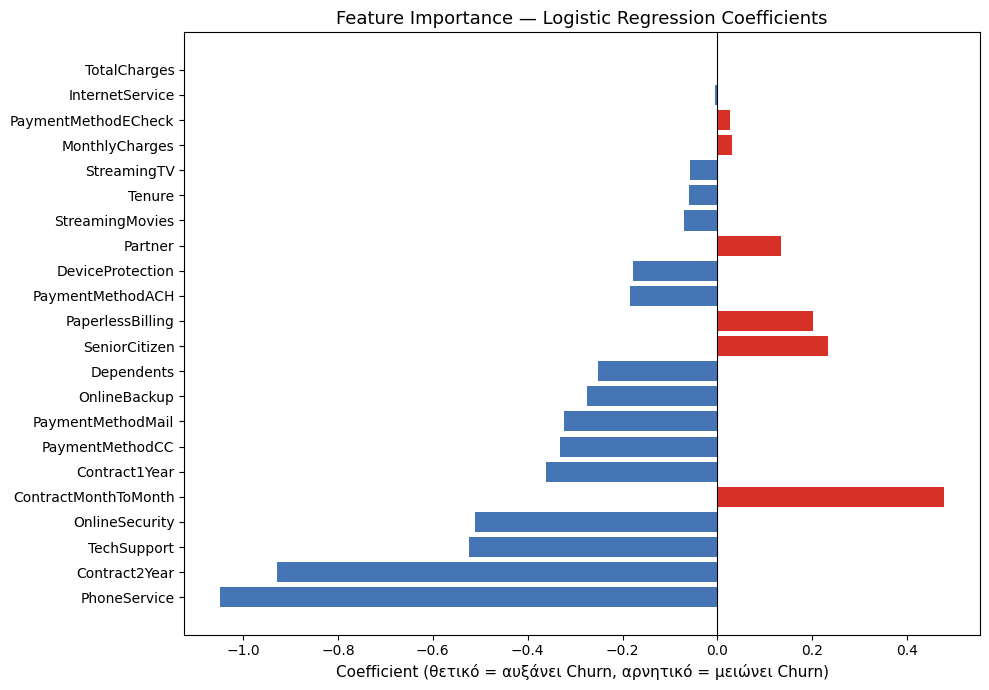


🔝 Top 5 features που αυξάνουν Churn:
             Feature  Coefficient
ContractMonthToMonth     0.477069
       SeniorCitizen     0.233018
    PaperlessBilling     0.202331
             Partner     0.134143
      MonthlyCharges     0.029590

🔽 Top 5 features που μειώνουν Churn:
       Feature  Coefficient
  PhoneService    -1.047678
 Contract2Year    -0.929043
   TechSupport    -0.522943
OnlineSecurity    -0.511381
 Contract1Year    -0.362197


In [74]:
# Feature Importance βάσει coefficients (Logistic Regression)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (θετικό = αυξάνει Churn, αρνητικό = μειώνει Churn)', fontsize=11)
plt.title('Feature Importance — Logistic Regression Coefficients', fontsize=13)
plt.tight_layout()
plt.show()

print("\n🔝 Top 5 features που αυξάνουν Churn:")
print(coef_df[coef_df['Coefficient'] > 0].head(5).to_string(index=False))

print("\n🔽 Top 5 features που μειώνουν Churn:")
print(coef_df[coef_df['Coefficient'] < 0].head(5).to_string(index=False))

**Ανάλυση και Ερμηνεία Αποτελεσμάτων**

Με βάση το γράφημα των Συντελεστών της Λογιστικής Παλινδρόμησης (Feature Importance), μπορούμε να εξάγουμε κρίσιμα συμπεράσματα για τη συμπεριφορά των πελατών:

**Θετικοί Συντελεστές (Αύξηση Churn)**: Οι μεταβλητές με τις μεγαλύτερες θετικές τιμές (π.χ. ContractMonthToMonth ή SeniorCitizen) υποδεικνύουν τα χαρακτηριστικά εκείνα που αυξάνουν την πιθανότητα ένας πελάτης να διακόψει τη σύνδεσή του. Για παράδειγμα, οι πελάτες με μηνιαίο συμβόλαιο φαίνεται να έχουν πολύ υψηλότερη τάση αποχώρησης σε σχέση με εκείνους που έχουν μακροχρόνια συμβόλαια.

**Αρνητικοί Συντελεστές (Μείωση Churn)**: Μεταβλητές όπως το Tenure (διάρκεια παραμονής) ή το TotalCharges συχνά λειτουργούν ως "ασπίδα". Όσο αυξάνονται αυτές οι τιμές, τόσο μειώνεται η πιθανότητα αποχώρησης, υποδηλώνοντας ότι οι πιστοί πελάτες (long-term customers) είναι λιγότερο πιθανό να εγκαταλείψουν την εταιρεία.

---
## **Σύνοψη Pipeline**

| Βήμα Azure | Module | Python Αντίστοιχο |
|---|---|---|
| 1 | CustomerChurnClean | `pd.read_csv()` |
| 2 | Clean Missing Data | `df.dropna()` + encoding |
| 3 | Split Data | `train_test_split()` |
| 4 | Two-Class Logistic Regression | `LogisticRegression()` |
| 5 | Train Model | `.fit(X_train, y_train)` |
| 6 | Score Model | `.predict()` + `.predict_proba()` |
| 7 | Evaluate Model | `accuracy_score`, `roc_auc_score`, κ.λπ. |